## ML Classical Baselines

In [1]:
import pandas as pd
from IPython.display import display

from utils.config import (
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
)
from utils.ML.ml_pipeline import (
    best_confusion_predictions,
    get_cache_path,
    get_results_path,
    load_all_predictions,
    load_feature_dataframes,
    load_lovo_summary_tables,
    load_or_build_none_reference_features,
    load_params_lookup,
    load_raw_csi_data,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
    print_normalization_discriminability,
    run_global_baselines,
    run_optional_grid_search,
    save_analysis_tables,
    save_lovo_analysis_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_block_vs_lovo_position_accuracy,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_lovo_fold_spread,
    plot_csi_magnitude_stages,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)

#### Project Configurations

In [2]:
CALIBRATION_MODE = "rssi"   # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline",  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"  # per_session | per_user | global (empty_baseline only)
SHOW_MAGNITUDE_PLOT = True

MAGNITUDE_PLOT_OPTIONS = {
    "position": "D-5",
    "user": "03",
    "trial": "01",
    "anchor_pair": 9,
    "packet_count": 60,
    "packet_selection": "middle",
    "normalized_limit_percentile": 99.0,
    "surface_elevation": 28,
    "surface_azimuth": -135,
    "save": False,
    "output_directory": "outputs/magnitude_plots",
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

MODELS_TO_RUN = ("RF", "KNN", "SVM")
SPLIT_MODES = ("block", "lovo")  # cross_session, lovo, random, block
RUN_CLASSIFICATION = False
RUN_GRID_SEARCH = False
REQUIRE_TUNED_PARAMS = True  # True -> require an exact matching grid-search run
FORCE_RETRAIN = False
SAVE_PREDICTIONS = True
N_JOBS = 8

BLOCK_COUNT = 10
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0
SVM_FUSION_FALLBACK_SECONDS = 30 * 60

CONFUSION_DATASET = "Fusion"
CONFUSION_MODEL = "best"      # "best", "RF", "KNN", or "SVM"

SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
if preproc_opts.get("normalization") == "empty_baseline":
    preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)
feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
tables_dir = results_dir / "tables"
plots_dir = results_dir / "plots"
for directory in (tables_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")

Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results


## Raw Data

In [4]:
loaded_csi_data = load_raw_csi_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
    return_magnitude_stages=SHOW_MAGNITUDE_PLOT,
)
magnitude_data, csv_diagnostics = loaded_csi_data[:2]
magnitude_plot_stages = loaded_csi_data[2] if SHOW_MAGNITUDE_PLOT else None

Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19


[Z-0 inventory]
  total Z-0 files found: 171
  Z-0 count per (user, trial):
    (user=01, trial=01): 19
    (user=01, trial=02): 19
    (user=02, trial=01): 19
    (user=03, trial=01): 19
    (user=03, trial=02): 19
    (user=04, trial=01): 19
    (user=05, trial=01): 19
    (user=05, trial=02): 19
    (user=06, trial=01): 19
  breakdown by user / esp / trial:
    user=01 esp=01 trial=01: 1
    user=01 esp=01 trial=02: 1
    user=01 esp=02 trial=01: 1
    user=01 esp=02 trial=02: 1
    user=01 esp=03 trial=01: 1
    user=01 esp=03 trial=02: 1
    user=01 esp=04 trial=01: 1
    user=01 esp=04 trial=02: 1
    user=01 esp=05 trial=01: 1
    user=01 esp=05 trial=02: 1
    user=01 esp=07 trial=01: 1
    user=01 esp=07 trial=02: 1
    user=01 esp=08 trial=01: 1
    user=01 esp=08 trial=02: 1
    user=01 esp=09 trial=01: 1
    user=01 esp=09 trial=02: 1
    user=01 esp=10 trial=01: 1
    user=01 esp=10 trial=02: 1
    user=01 esp=11 trial=01: 1
    user=01 esp=11 trial=02: 1
    user=01 esp=1

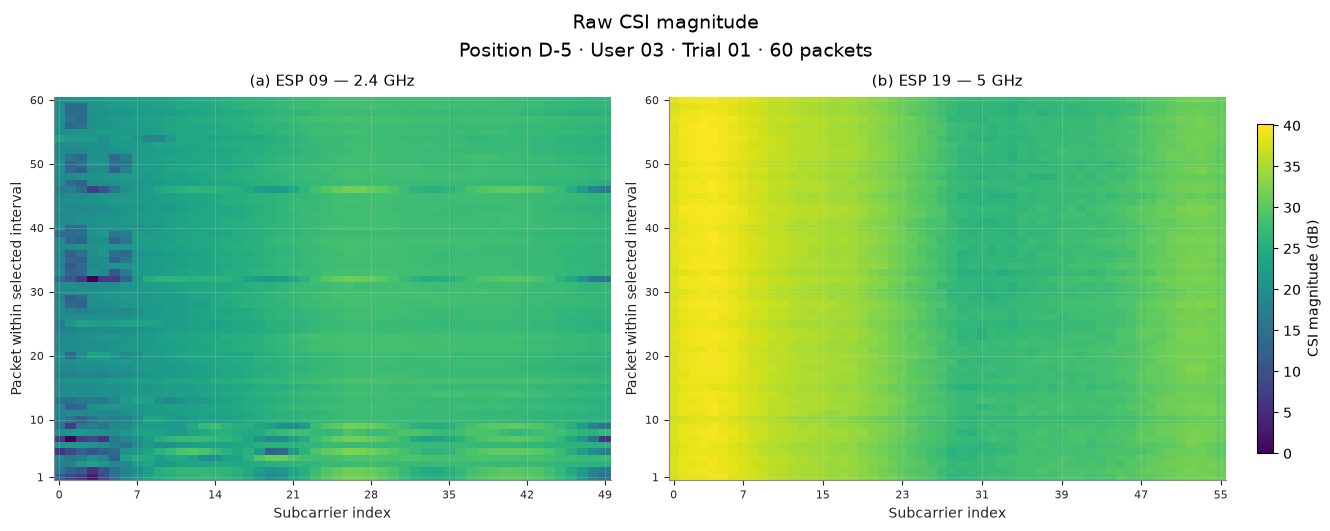

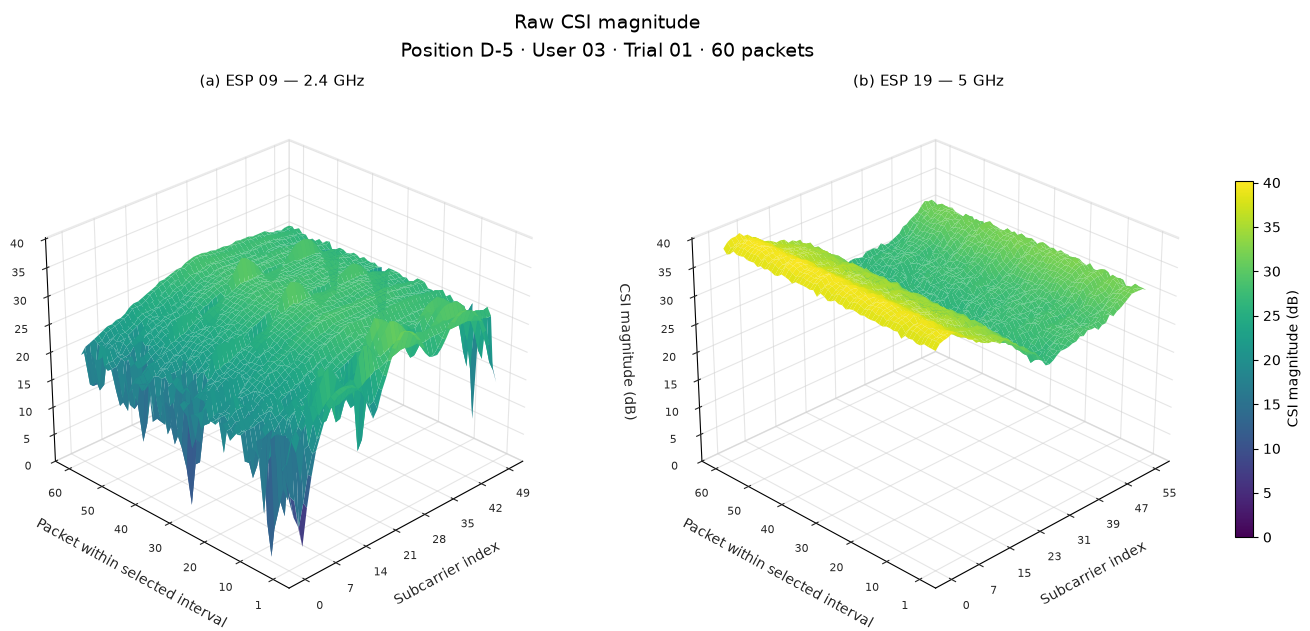

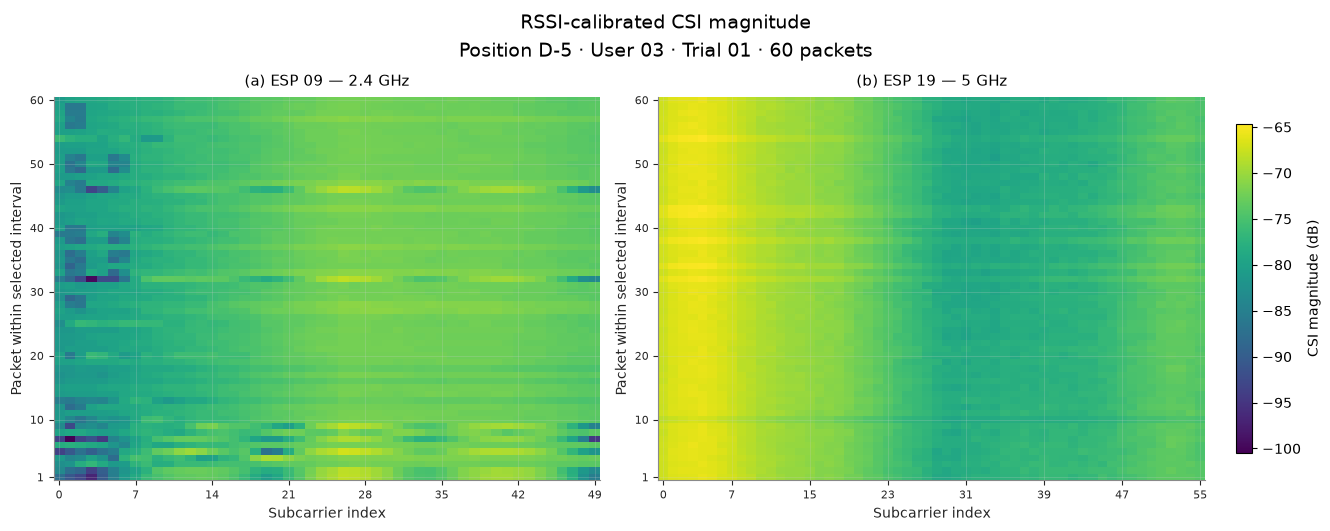

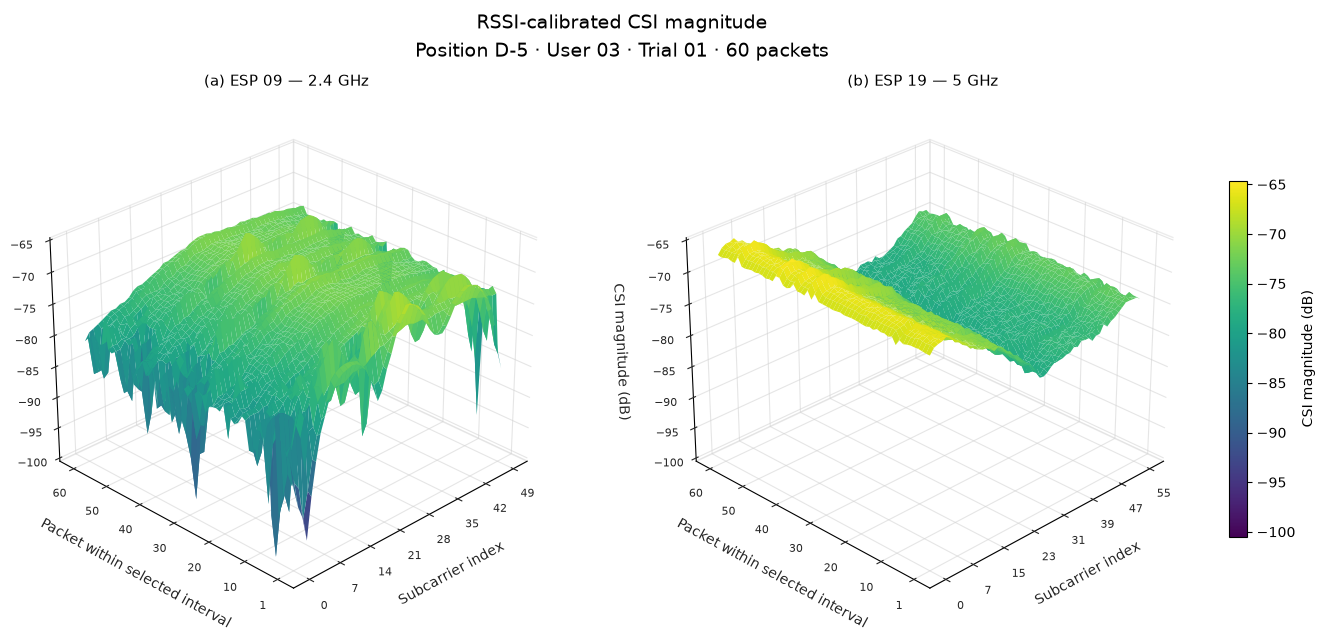

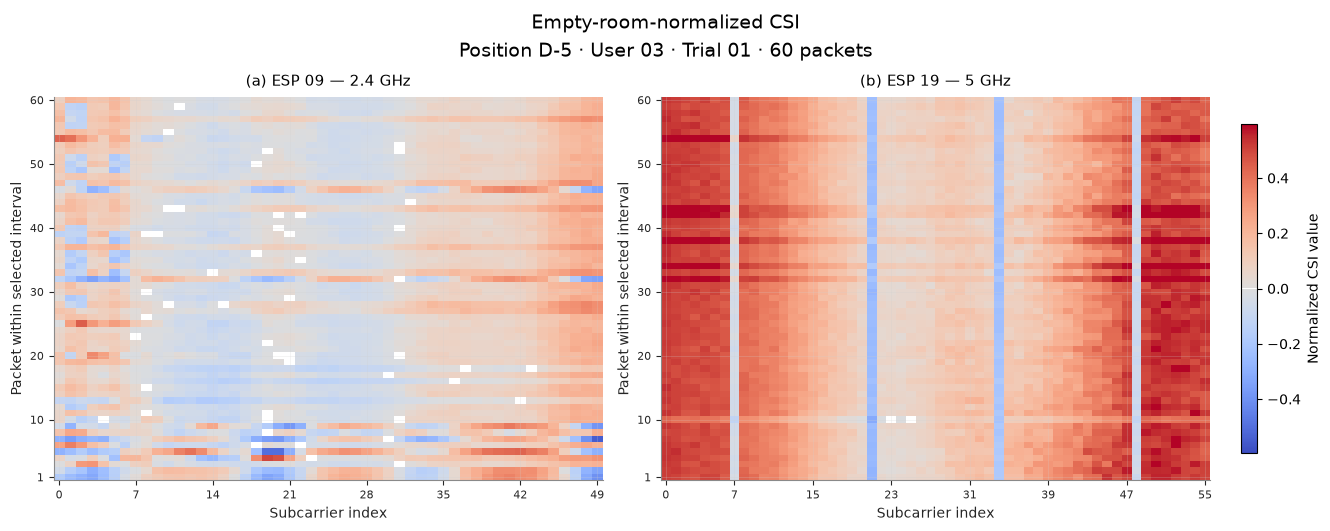

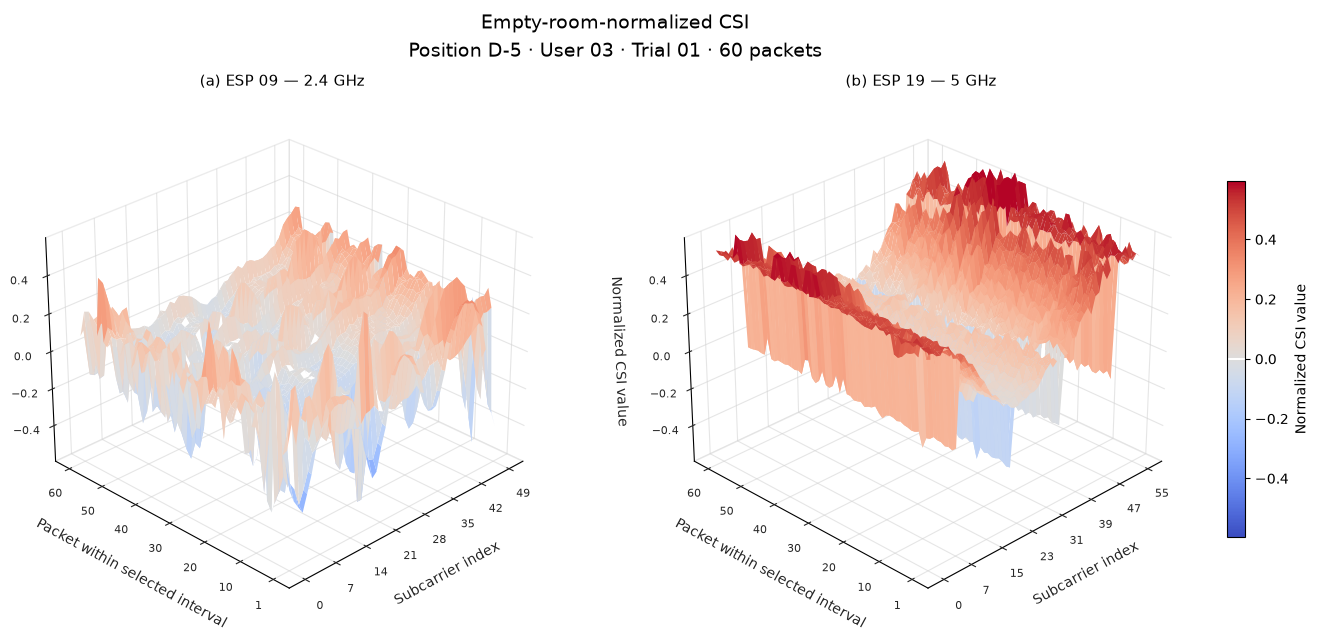

In [5]:
if SHOW_MAGNITUDE_PLOT:
    plot_csi_magnitude_stages(magnitude_plot_stages, **MAGNITUDE_PLOT_OPTIONS)

#### Feature Dataframes

In [6]:
feature_dataframes = load_feature_dataframes(
    magnitude_data,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    bands_to_run=BANDS_TO_RUN,
)

none_reference_dataframes = (
    feature_dataframes
    if preproc_opts.get("normalization") == "none"
    else load_or_build_none_reference_features(
        magnitude_data,
        active_preproc_opts=preproc_opts,
        feat_opts=feat_opts,
    )
)
fisher_diagnostics = print_normalization_discriminability(
    feature_dataframes,
    normalization=preproc_opts.get("normalization", "none"),
    reference_feature_dataframes=none_reference_dataframes,
    bands_to_run=BANDS_TO_RUN,
)
display(fisher_diagnostics)
del magnitude_data


[features] resolved cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/2_4ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/5ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/fusion.parquet
2.4 GHz: 13588 windows, 2708 columns
5 GHz: 14478 windows, 3368 columns
Fusion: 13568 windows, 6068 columns
[normalization diagnostic] none reference cache: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-none/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc

,dataset,normalization,median_fisher_ratio,none_median_fisher_ratio
0,2.4 GHz,empty_baseline,0.069480,0.028427
1,5 GHz,empty_baseline,0.067411,0.030535
2,Fusion,empty_baseline,0.069267,0.029641


#### Model Parameters

In [7]:
params_lookup = {}
if RUN_GRID_SEARCH:
    print("Parameter lookup deferred until the requested grid search completes.")
else:
    params_lookup = load_params_lookup(
        results_dir,
        models_to_run=MODELS_TO_RUN,
        bands_to_run=BANDS_TO_RUN,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        require_tuned_params=REQUIRE_TUNED_PARAMS,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
    )
    for key, value in params_lookup.items():
        print(f"{key}: {value}")

[tuned params] exact runs.csv match: RF / 2.4 GHz / run_id=ml__rf__2_4ghz__grid_search__ebl-session__s42__d8d534
[tuned params] exact runs.csv match: RF / 5 GHz / run_id=ml__rf__5ghz__grid_search__ebl-session__s42__0249b6
[tuned params] exact runs.csv match: RF / Fusion / run_id=ml__rf__fusion__grid_search__ebl-session__s42__666a25
[tuned params] exact runs.csv match: KNN / 2.4 GHz / run_id=ml__knn__2_4ghz__grid_search__ebl-session__s42__d47768
[tuned params] exact runs.csv match: KNN / 5 GHz / run_id=ml__knn__5ghz__grid_search__ebl-session__s42__80bca5
[tuned params] exact runs.csv match: KNN / Fusion / run_id=ml__knn__fusion__grid_search__ebl-session__s42__5b6367
[tuned params] exact runs.csv match: SVM / 2.4 GHz / run_id=ml__svm__2_4ghz__grid_search__ebl-session__s42__3be980
[tuned params] exact runs.csv match: SVM / 5 GHz / run_id=ml__svm__5ghz__grid_search__ebl-session__s42__0f2dc1
[tuned params] exact runs.csv match: SVM / Fusion / run_id=ml__svm__fusion__grid_search__ebl-session

##### Optional Grid Search

In [8]:
grid_ran = run_optional_grid_search(
    feature_dataframes,
    run_grid_search=RUN_GRID_SEARCH,
    results_dir=results_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
if grid_ran:
    raise SystemExit("RUN_GRID_SEARCH=True completed; set it to False before running experiments.")

#### Global 52-Class Baselines

In [9]:
if RUN_CLASSIFICATION:
    global_summary, global_predictions_by_key = run_global_baselines(
        feature_dataframes,
        params_lookup=params_lookup,
        models_to_run=MODELS_TO_RUN,
        bands_to_run=BANDS_TO_RUN,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
        n_jobs=N_JOBS,
        results_dir=results_dir,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        force_retrain=FORCE_RETRAIN,
        save_predictions=SAVE_PREDICTIONS,
        svm_fallback_seconds=SVM_FUSION_FALLBACK_SECONDS,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
    display(global_summary)
    run_registry = pd.read_csv(results_dir / "runs.csv")
    active_run_ids = run_registry.loc[
        run_registry["model"].isin([model.lower() for model in MODELS_TO_RUN])
        & run_registry["split"].isin(SPLIT_MODES),
        "run_id",
    ]
    if active_run_ids.empty:
        raise RuntimeError("No active run_id is available for plot storage.")
    plots_dir = results_dir / "plots" / active_run_ids.iloc[0]
    plots_dir.mkdir(parents=True, exist_ok=True)
else:
    print("Classification skipped because RUN_CLASSIFICATION is False.")


Classification skipped because RUN_CLASSIFICATION is False.


#### Analysis Tables

In [10]:
all_global_predictions = load_all_predictions(
    results_dir,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
)

master_table = master_results_table(
    all_global_predictions,
    summary_path=results_dir / "runs.csv",
)
per_room_table = per_room_position_accuracy_table(all_global_predictions)
save_analysis_tables(master_table, per_room_table, tables_dir=tables_dir)

display(master_table)
display(per_room_table)

FileNotFoundError: runs.csv contains no rows matching the requested models/bands/splits.

#### LOVO cross-user analysis


In [ ]:
if "lovo" in SPLIT_MODES:
    lovo_per_fold, lovo_summary = load_lovo_summary_tables(results_dir)
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)
    save_lovo_analysis_table(lovo_table, tables_dir=tables_dir)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('lovo rf fold spread')}.png",
    )
    plot_block_vs_lovo_position_accuracy(
        globals().get("global_summary", master_table),
        lovo_summary,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('block vs lovo rf position accuracy')}.png",
    )

    display(lovo_table)
    display(
        lovo_per_fold.loc[
            lovo_per_fold["model"].str.upper() == "RF"
        ]
    )
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")

#### Analysis Figures

In [ ]:
if SHOW_CDF_BY_BAND:
    for band in BANDS_TO_RUN:
        plot_localization_error_cdf_by_model(
            all_global_predictions,
            dataset=band,
            save_path=plots_dir / f"cdf_by_model_{_slugify(band)}.png",
        )

if SHOW_CDF_BY_MODEL:
    for model in MODELS_TO_RUN:
        model_predictions = all_global_predictions.loc[all_global_predictions["model"] == model]
        plot_band_error_cdf(
            model_predictions,
            model_label=model,
            split_modes=SPLIT_MODES,
            band_order=BANDS_TO_RUN,
            save_path=plots_dir,
        )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_global_predictions,
        models=MODELS_TO_RUN,
        bands=BANDS_TO_RUN,
        save_path=plots_dir / "boxplot_model_band_distance_error.png",
    )

#### Confusion Matrix And Floor Plan

In [ ]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_global_predictions,
    master_table,
    dataset=CONFUSION_DATASET,
    model=CONFUSION_MODEL,
)
print(f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET}")

if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=f"{CONFUSION_DATASET} / {confusion_model} localization heatmap",
        save_path=plots_dir / f"floor_plan_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.png",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=plots_dir / f"confusion_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.png",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = plots_dir / f"confusion_by_room_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )